# qGAN Experiment Tutorial

Use this notebook to run or load one selected experiment, run or load a battery, and analyze completed checkpoints.


## 1. Setup

Run this notebook from inside the repository or from `qgan/notebooks`. The cell below makes `qgan/src` importable without installing the package.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
qgan_dir = next(
    (
        candidate
        for root in (cwd, *cwd.parents)
        for candidate in (root, root / "qgan")
        if (candidate / "src" / "qgan_v2").is_dir()
    ),
    None,
)
if qgan_dir is None:
    raise RuntimeError("Could not find the qgan project directory.")

src_path = qgan_dir / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
repo_root = qgan_dir.parent
print({"qgan_dir": qgan_dir, "repo_root": repo_root})

{'qgan_dir': PosixPath('/home/benat/Qiskit-IBM/qgan'), 'repo_root': PosixPath('/home/benat/Qiskit-IBM')}


In [2]:
from qgan_v2.analysis import ThesisReport
from qgan_v2.analysis.report import display_rows
from qgan_v2.experiments import BatteryExperiments, SingleExperiment, manage_runtime_account
from qgan_v2.implementations.registry import IMPLEMENTATIONS
from qgan_v2.visualization import get_visual_config, run_visualization

sorted(IMPLEMENTATIONS)

['manual_estimator', 'qml_torch', 'runtime_packed']

## 2. IBM Runtime Credentials

This cell is optional. Enable it only when you need to save or verify IBM Runtime credentials.


In [3]:
SAVE_RUNTIME_ACCOUNT = False
CHECK_RUNTIME_ACCOUNT = False

backend_count = manage_runtime_account(
    save=SAVE_RUNTIME_ACCOUNT,
    check=CHECK_RUNTIME_ACCOUNT,
)
if backend_count is not None:
    print("Available backends:", backend_count)

## 3. Single Experiment

The first YAML file in `configs/singles` is selected by default. Set `single_config_path` to choose another one.


In [4]:
single_config_path = repo_root / "qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/config.yaml"

single = SingleExperiment.select(
    single_config_path,
    fallback_directory=qgan_dir / "configs" / "singles",
)
single.summary()

{'config': '/home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/config.yaml',
 'run_id': 'base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0',
 'checkpoint': '/home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/training_data.pth',
 'checkpoint_exists': True}

### Run Or Load

Choose one boolean. Function arguments stay in the function call.


In [5]:
RUN_SINGLE_EXPERIMENT = False
state = single.run_or_load(run=RUN_SINGLE_EXPERIMENT, reset_data=False)
print("loaded state:", single.checkpoint)

loaded state: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/training_data.pth


### Inspect Checkpoint


In [6]:
print("current_epoch:", state.current_epoch)
print("best_eval:", state.metrics.best_eval())

current_epoch: 238
best_eval: 3.032940695344694


### Visualize


In [7]:
VISUALIZE_EXPERIMENT_RESULTS = False

if single.checkpoint.exists() and VISUALIZE_EXPERIMENT_RESULTS:
    run_visualization(
        single.config_path,
        get_visual_config({
            "draw_circuits": False,
            "draw_hardware_layout": True,
            "draw_probs": False,
            "draw_images": True,
            "draw_results": True,
        }),
    )

## 4. Battery Experiments

The first YAML file in `configs/batteries` is selected by default. Set `battery_path` to choose another one.


In [8]:
battery_path = repo_root / "qgan/configs/batteries/train/train_times_gpu.yaml"

battery = BatteryExperiments.select(
    battery_path,
    fallback_directory=qgan_dir / "configs" / "batteries",
)
print("battery:", battery.battery_path)

battery: /home/benat/Qiskit-IBM/qgan/configs/batteries/train/train_times_gpu.yaml


### Run Or Load

Set `RUN_BATTERY_EXPERIMENTS = True` to run the battery. Leave it `False` to load existing checkpoints. In both cases, `battery.states` is populated from checkpoint files.


In [9]:
RUN_BATTERY_EXPERIMENTS = False

battery.run_or_load(
    run=RUN_BATTERY_EXPERIMENTS,
    reset_data=False,
    reset_real_backend_info=False,
    stop_on_error=False,
    overwrite=False,
)

{'battery': '/home/benat/Qiskit-IBM/qgan/configs/batteries/train/train_times_gpu.yaml',
 'config_files': 265,
 'valid_config_files': 265,
 'invalid_config_files': 0,
 'loaded_states': 237,
 'missing_checkpoints': 28}

### Battery Summary


In [10]:
display_rows(battery.config_rows(limit=20))
remaining = len(battery.valid_config_files) - 20
if remaining > 0:
    print("...", remaining, "more configs")

{'run_id': 'amp-qml_torch-q16-noiseless-PSR-aerCPU-rand0-seed0', 'done': False, 'loaded': False, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/times/amp-qml_torch-q16-noiseless-PSR-aerCPU-rand0-seed0/config.yaml'}
{'run_id': 'amp-qml_torch-q16-noiseless-PSR-aerCPU-rand1-seed0', 'done': False, 'loaded': False, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/times/amp-qml_torch-q16-noiseless-PSR-aerCPU-rand1-seed0/config.yaml'}
{'run_id': 'amp-qml_torch-q16-noiseless-PSR-aerGPU-rand0-seed0', 'done': False, 'loaded': False, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/times/amp-qml_torch-q16-noiseless-PSR-aerGPU-rand0-seed0/config.yaml'}
{'run_id': 'amp-qml_torch-q16-noiseless-PSR-aerGPU-rand1-seed0', 'done': False, 'loaded': False, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/times/amp-qml_torch-q16-noiseless-PSR-aerGPU-rand1-seed0/config.yaml'}
{'run_id': 'amp-qml_torch-q16-noiseless-REG-aerCPU-rand0-seed0', 'done': False, 'loaded': False, 'config_fil

## 5. Implementation Adapters

Quick view of implementations in the battery configs loaded above.


In [11]:
display_rows(
    battery.implementation_rows(project_directory=qgan_dir, limit=20)
)
remaining = len(battery.valid_config_files) - 20
if remaining > 0:
    print("...", remaining, "more configs")

{'config_file': 'data/train/times/amp-qml_torch-q16-noiseless-PSR-aerCPU-rand0-seed0/config.yaml', 'implementation': 'qml_torch', 'preset': 'amp', 'gradient': 'PSR'}
{'config_file': 'data/train/times/amp-qml_torch-q16-noiseless-PSR-aerCPU-rand1-seed0/config.yaml', 'implementation': 'qml_torch', 'preset': 'amp', 'gradient': 'PSR'}
{'config_file': 'data/train/times/amp-qml_torch-q16-noiseless-PSR-aerGPU-rand0-seed0/config.yaml', 'implementation': 'qml_torch', 'preset': 'amp', 'gradient': 'PSR'}
{'config_file': 'data/train/times/amp-qml_torch-q16-noiseless-PSR-aerGPU-rand1-seed0/config.yaml', 'implementation': 'qml_torch', 'preset': 'amp', 'gradient': 'PSR'}
{'config_file': 'data/train/times/amp-qml_torch-q16-noiseless-REG-aerCPU-rand0-seed0/config.yaml', 'implementation': 'qml_torch', 'preset': 'amp', 'gradient': 'REG'}
{'config_file': 'data/train/times/amp-qml_torch-q16-noiseless-REG-aerCPU-rand1-seed0/config.yaml', 'implementation': 'qml_torch', 'preset': 'amp', 'gradient': 'REG'}
{'co

## 6. Thesis Results Analysis

The results follow this order: time and feasibility; presets; execution type; gradient method; randomness; scaling; and implementation/packing validation.

Unless stated otherwise, quality figures use completed 1000-epoch simulator runs. CPU/GPU copies of the same scientific run are collapsed for quality analysis, while device remains explicit in timing. Comparison figures show evaluation only, with faint run traces and median/IQR shadows showing variation across seeds. The sole exception is the preset learning-dynamics comparison in Section 2.1, which retains the joined blue generator-loss, red discriminator-loss, and orange evaluation layout.


### Analysis setup and figure export

Set `EXPORT_FIGURES = True` to save PDF and 300-dpi PNG versions under `qgan/figures/thesis_results`. Each subsection keeps its scientific filters and comparison choices visible in the notebook; reusable loading and plotting mechanics live in `qgan_v2.analysis`. KL divergence (`base`) and image-gradient scores (`ang`/`amp`) are faceted rather than pooled because their scales are not comparable.


In [12]:
EXPORT_FIGURES = False
GPU_MODEL_LABEL = "RTX6000"  # Change if another GPU timing battery is loaded.
PRESET_ORDER = ("base", "ang", "amp")
GRADIENT_ORDER = ("PSR", "REG", "SPSA")

report = ThesisReport.load(
    qgan_dir,
    export_figures=EXPORT_FIGURES,
    gpu_model_label=GPU_MODEL_LABEL,
)
report.results.summary()

{'raw_convergence/case-study_configs': 717,
 'completed_deduplicated_simulator_runs': 374,
 'completed_five_epoch_timing_runs': 222,
 'usable_real_hardware_runs': 3,
 'usable_implementation_validation_runs': 8,
 'evaluation_families': {'gradient': 223, 'kl': 151}}

### 1. Time, Cost, and Feasibility

Timing comes first so the reader knows which experiments were computationally practical before interpreting model quality.


#### 1.1 Time analysis

These panels use completed five-epoch timing batteries. Median time per epoch is reported because it is less sensitive to a slow initialization epoch. The factors are preset, execution type, gradient method, and `rand0`/`rand1`.

The timing environments are the one-CPU battery (`CPU/1`), the explicit four-CPU battery (`CPU/4`), and the configured GPU battery. Every series is plotted on the exact categorical tick—there is no horizontal series offset.


timing environments: ['CPU/1', 'CPU/4', 'GPU (RTX6000)']


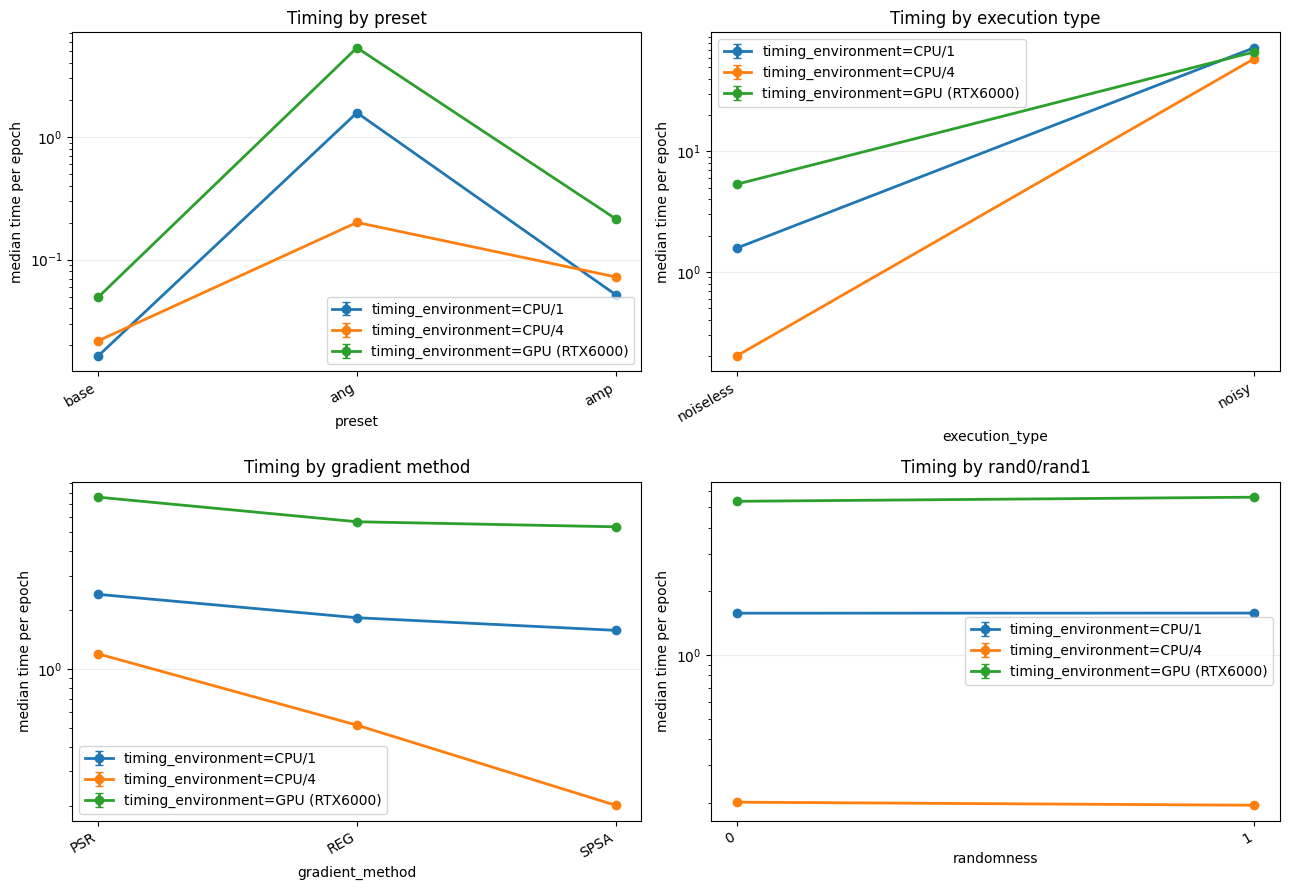

In [13]:
TIMING_BASELINE = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
}
primary_timing = report.timing_analysis(
    baseline_filters=TIMING_BASELINE,
    factor_levels={"randomness": (0, 1)},
)

#### 1.2 Experimental limitations and feasibility

This subsection records the known resource boundary for each omitted or unfinished experiment class. It deliberately excludes `fake_real`, which is an implementation-validation mode rather than a feasibility result. The completion matrix counts all requests from the current convergence and timing batteries plus the commented noisy-q16 convergence plan. CPU/GPU convergence copies are collapsed into one scientific request, while timing devices remain separate. The adjacent bars partition the matrix's incomplete requests by limitation, so their per-qubit totals match the incomplete counts in the matrix. Files ending in `_old` are excluded throughout.

The categories distinguish time cost, unavailable real-hardware execution time, statevector transpilation limits, and CPU memory limits. They should be interpreted as experimental design constraints, not model-quality outcomes.


non-old convergence battery references: ['train_conv_cpu.yaml', 'train_conv_gpu.yaml', 'train_conv_remaining_cpu_065.yaml', 'train_conv_remaining_cpu_068.yaml', 'train_conv_remaining_cpu_069.yaml', 'train_conv_remaining_cpu_081.yaml', 'train_conv_remaining_cpu_092.yaml', 'train_conv_remaining_cpu_107.yaml', 'train_conv_remaining_cpu_108.yaml', 'train_conv_remaining_cpu_109.yaml', 'train_conv_rh.yaml', 'train_psr_noisy_q4_amp_seed0_cpu.yaml', 'train_psr_noisy_q4_amp_seed1_cpu.yaml', 'train_psr_noisy_q4_amp_seed2_cpu.yaml', 'train_psr_noisy_q4_ang_seed0_cpu.yaml', 'train_psr_noisy_q4_ang_seed1_cpu.yaml', 'train_psr_noisy_q4_ang_seed2_cpu.yaml', 'train_psr_noisy_q4_base_seed0_cpu.yaml', 'train_psr_noisy_q4_base_seed1_cpu.yaml', 'train_psr_noisy_q4_base_seed2_cpu.yaml', 'train_psr_noisy_q8_amp_seed0_cpu.yaml', 'train_psr_noisy_q8_amp_seed1_cpu.yaml', 'train_psr_noisy_q8_amp_seed2_cpu.yaml', 'train_psr_noisy_q8_ang_seed0_cpu.yaml', 'train_psr_noisy_q8_ang_seed1_cpu.yaml', 'train_psr_noisy_q

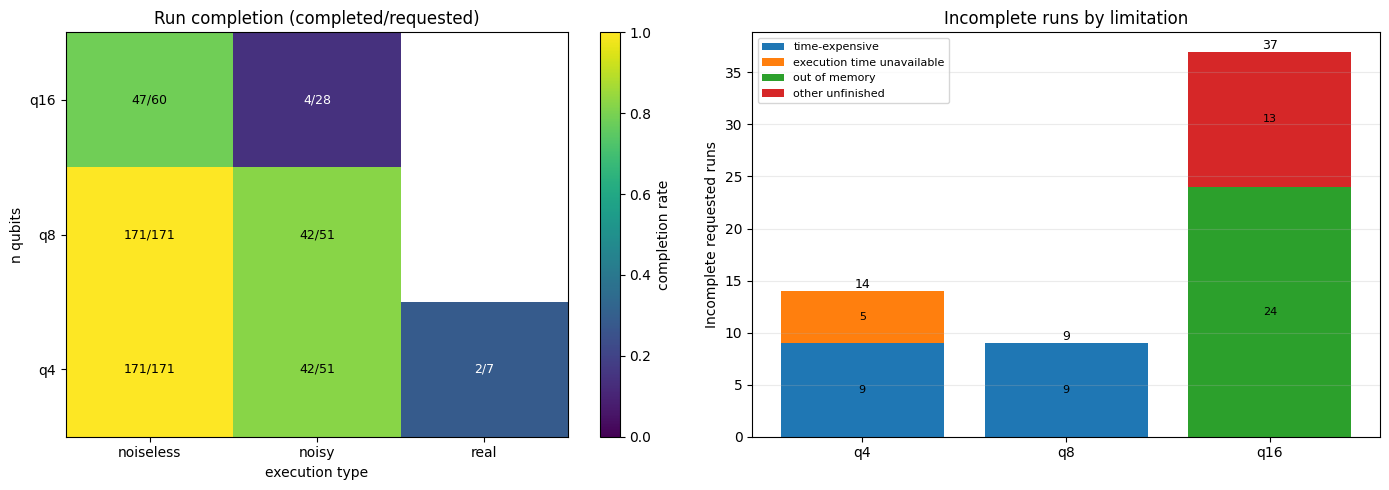

In [14]:
FEASIBILITY_BATTERY_DIR = qgan_dir / "configs" / "batteries" / "train"
INCLUDE_COMMENTED_Q16_REQUESTS = True

feasibility_results = report.feasibility_analysis(
    battery_dir=FEASIBILITY_BATTERY_DIR,
    include_commented_q16=INCLUDE_COMMENTED_Q16_REQUESTS,
)

### 2. Presets

This section establishes how the three data/encoding presets learn and then links the quantitative curves to generated outputs.


#### 2.1 Learning dynamics and best results

The comparison fixes noiseless PSR, `q4`, `rand0`, and seeds 0–2. Each preset has its own column because `base` minimizes KL divergence over a target probability distribution, while `ang` and `amp` use an image-gradient score.

Each preset column retains adversarial losses above evaluation: faint traces identify individual seed runs and solid lines with shadows give the median and IQR. The summary panels show best evaluation and the epoch at which it occurs; point color identifies the seed. This is the only subsection whose learning-dynamics graph includes generator and discriminator losses.


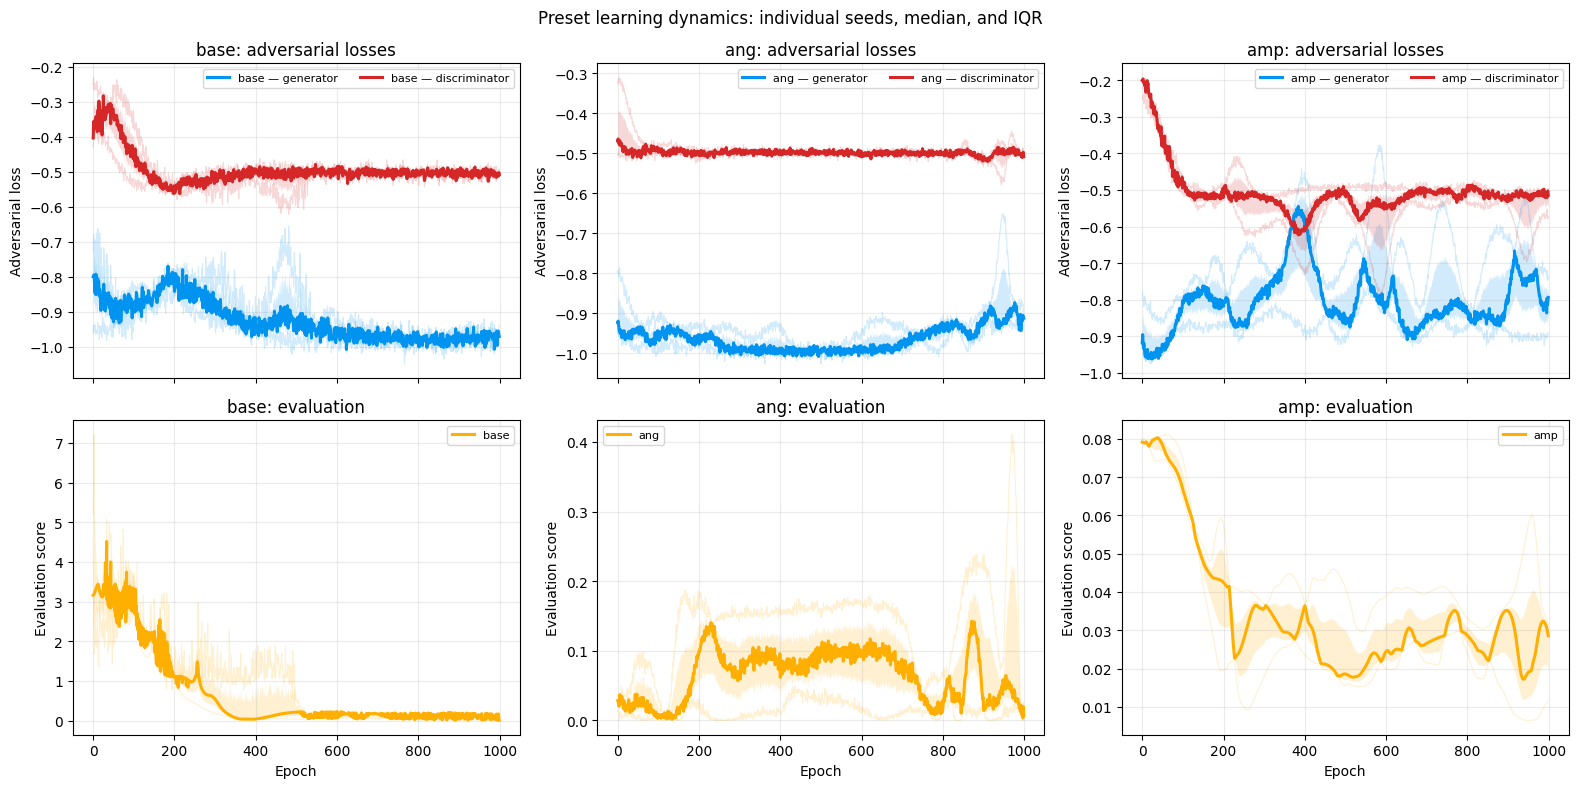

In [15]:
PRESET_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "PSR",
    "n_qubits": 4,
    "randomness": 0,
}
preset_runs = report.preset_learning_dynamics(
    filters=PRESET_FOCUS,
    presets=PRESET_ORDER,
)

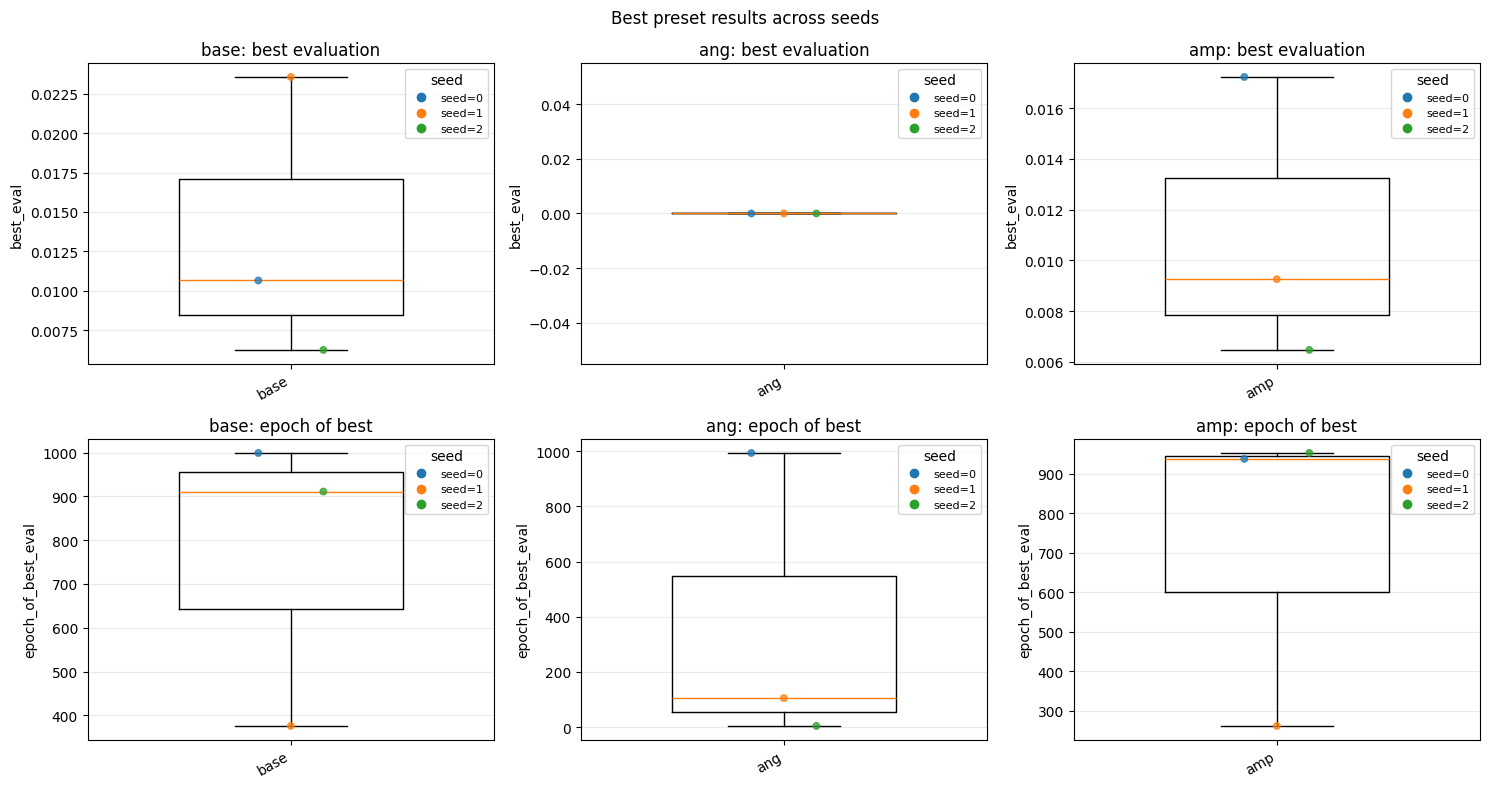

{'eval_method': 'gradient', 'preset': 'amp', 'completed_runs': 3, 'seeds': (0, 1, 2), 'median_best_eval': 0.009257595755188766, 'q25_best_eval': 0.007863034817550045, 'q75_best_eval': 0.013242806418764902, 'median_epoch_of_best_eval': 938.0}
{'eval_method': 'gradient', 'preset': 'ang', 'completed_runs': 3, 'seeds': (0, 1, 2), 'median_best_eval': 0.0, 'q25_best_eval': -0.0, 'q75_best_eval': -0.0, 'median_epoch_of_best_eval': 105.0}
{'eval_method': 'kl', 'preset': 'base', 'completed_runs': 3, 'seeds': (0, 1, 2), 'median_best_eval': 0.010651926471313883, 'q25_best_eval': 0.008447673538135969, 'q75_best_eval': 0.01710671319668662, 'median_epoch_of_best_eval': 911.0}


In [16]:
preset_performance = report.preset_best_results(
    preset_runs,
    presets=PRESET_ORDER,
)

#### 2.2 Initial, last, best, and target outputs

One completed noiseless `q4` run is chosen automatically for each preset using its best evaluation score. If runs tie, gradient methods are preferred in the requested order: PSR, REG, then SPSA. The initial, final-checkpoint, best-checkpoint, and target outputs are rendered together in one `1 × 4` row for each selected run, making the full qualitative change and any regression after the optimum directly visible.


In [17]:
OUTPUT_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "n_qubits": 4,
}
preset_output_manifest = report.select_preset_outputs(
    filters=OUTPUT_FOCUS,
    presets=PRESET_ORDER,
    gradient_priority=GRADIENT_ORDER,
)

{'preset': 'base', 'run_id': 'base-qml_torch-q4-noiseless-REG-aerCPU-rand0-seed2', 'gradient_method': 'REG', 'randomness': 0, 'seed': 2, 'evaluation_metric': 'kl', 'best_eval': 0.0012138125964342716, 'epoch_of_best_eval': 989, 'last_eval': 0.00312631188249346, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-REG-aerCPU-rand0-seed2/config.yaml'}
{'preset': 'ang', 'run_id': 'ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0', 'gradient_method': 'PSR', 'randomness': 0, 'seed': 0, 'evaluation_metric': 'gradient', 'best_eval': -0.0, 'epoch_of_best_eval': 994, 'last_eval': -0.0, 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml'}
{'preset': 'amp', 'run_id': 'amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0.25-seed0', 'gradient_method': 'PSR', 'randomness': 0.25, 'seed': 0, 'evaluation_metric': 'gradient', 'best_eval': -0.0, 'epoch_of_best_eval': 923, 'last_eval': 0.024289542199410288, 'config_file

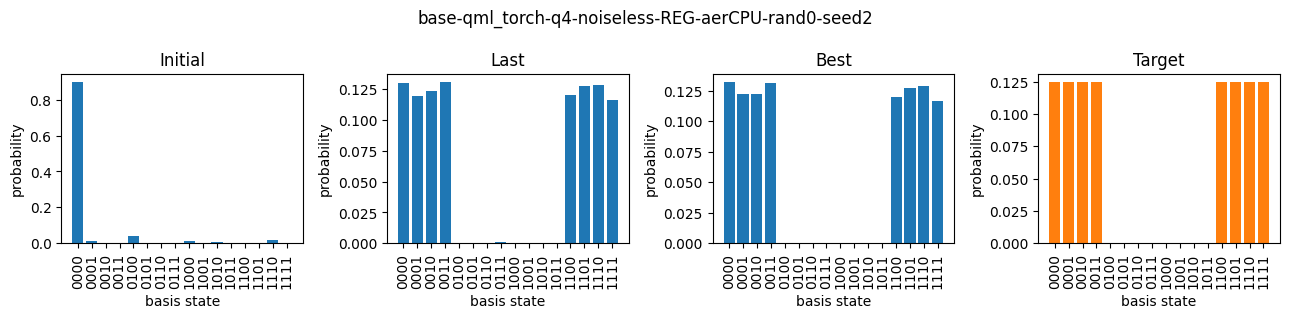

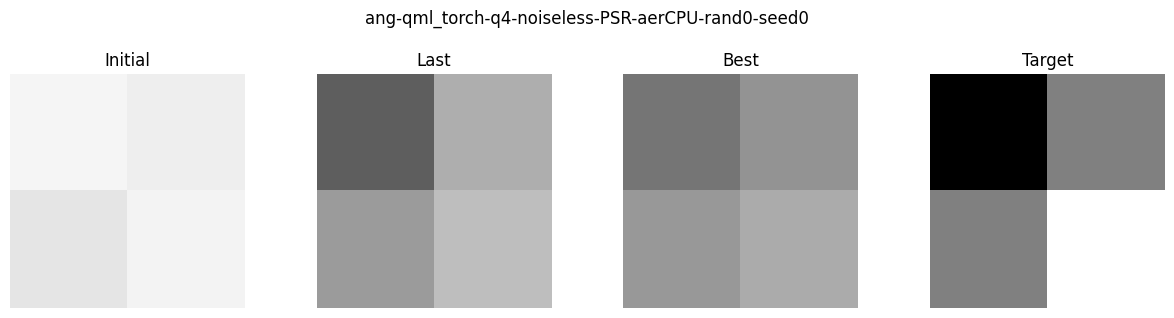

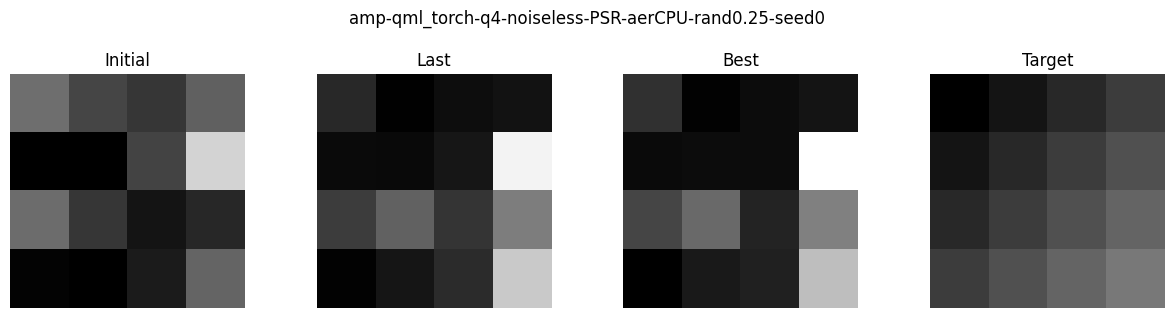

{'preset': 'base', 'run_id': 'base-qml_torch-q4-noiseless-REG-aerCPU-rand0-seed2', 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-REG-aerCPU-rand0-seed2/config.yaml', 'execution_type': 'noiseless', 'parameter_sets': ('initial', 'last', 'best'), 'random_seed': 0, 'evaluations': {'initial': {'score': nan, 'epoch': None}, 'last': {'score': 0.00312631188249346, 'epoch': 999}, 'best': {'score': 0.0012138125964342716, 'epoch': 989}}}
{'preset': 'ang', 'run_id': 'ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0', 'config_file': '/home/benat/Qiskit-IBM/qgan/data/train/ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml', 'execution_type': 'noiseless', 'parameter_sets': ('initial', 'last', 'best'), 'random_seed': 0, 'evaluations': {'initial': {'score': nan, 'epoch': None}, 'last': {'score': -0.0, 'epoch': 999}, 'best': {'score': -0.0, 'epoch': 994}}}
{'preset': 'amp', 'run_id': 'amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0.25-seed0', 'config_file': 

In [18]:
RENDER_PRESET_OUTPUTS = True
QUALITATIVE_RANDOM_SEED = 0

if RENDER_PRESET_OUTPUTS:
    rendered_output_manifest = report.render_preset_outputs(
        random_seed=QUALITATIVE_RANDOM_SEED
    )
else:
    print("Set RENDER_PRESET_OUTPUTS = True to create the four-panel output figures.")

### 3. Execution-Type Comparison

Simulation provides the replicated comparison; the much smaller real-hardware sample is separated so its evidential limits remain explicit.


#### 3.1 Noiseless versus noisy simulation

This comparison uses matched `q4`, SPSA, `rand0`, seeds 0–2. Each preset remains in its own metric column. Learning curves show evaluation only; summaries retain best evaluation and best epoch.


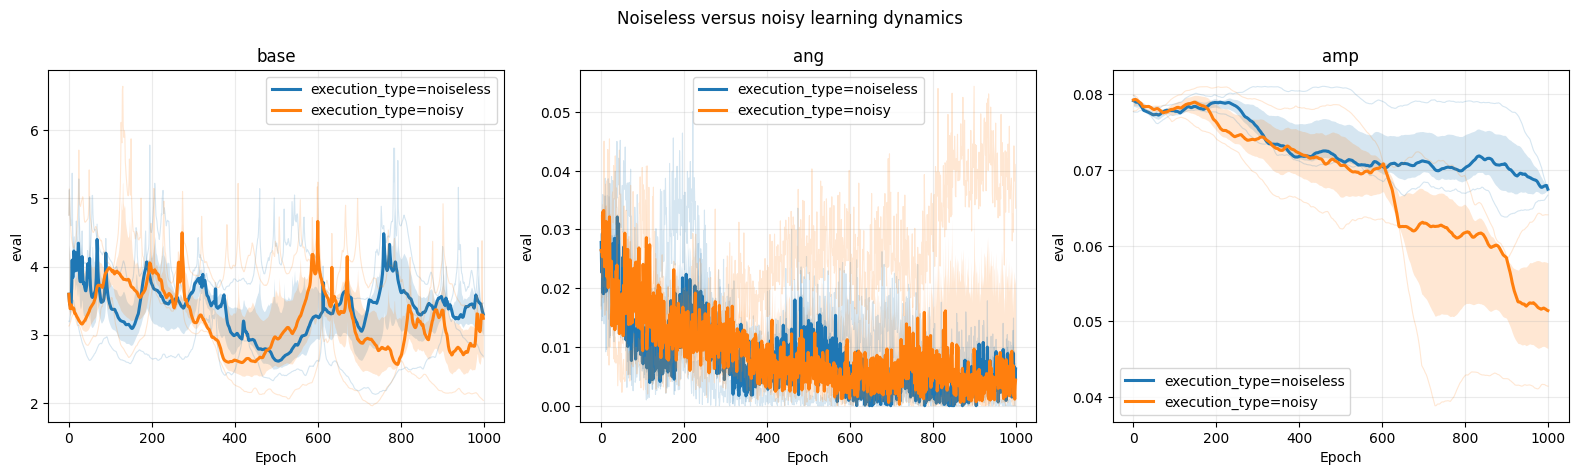

In [19]:
SIMULATION_EXECUTION_FOCUS = {
    "implementation": "qml_torch",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
    "execution_type": ("noiseless", "noisy"),
}
simulation_execution_runs = report.simulation_execution_dynamics(
    filters=SIMULATION_EXECUTION_FOCUS,
    presets=PRESET_ORDER,
)

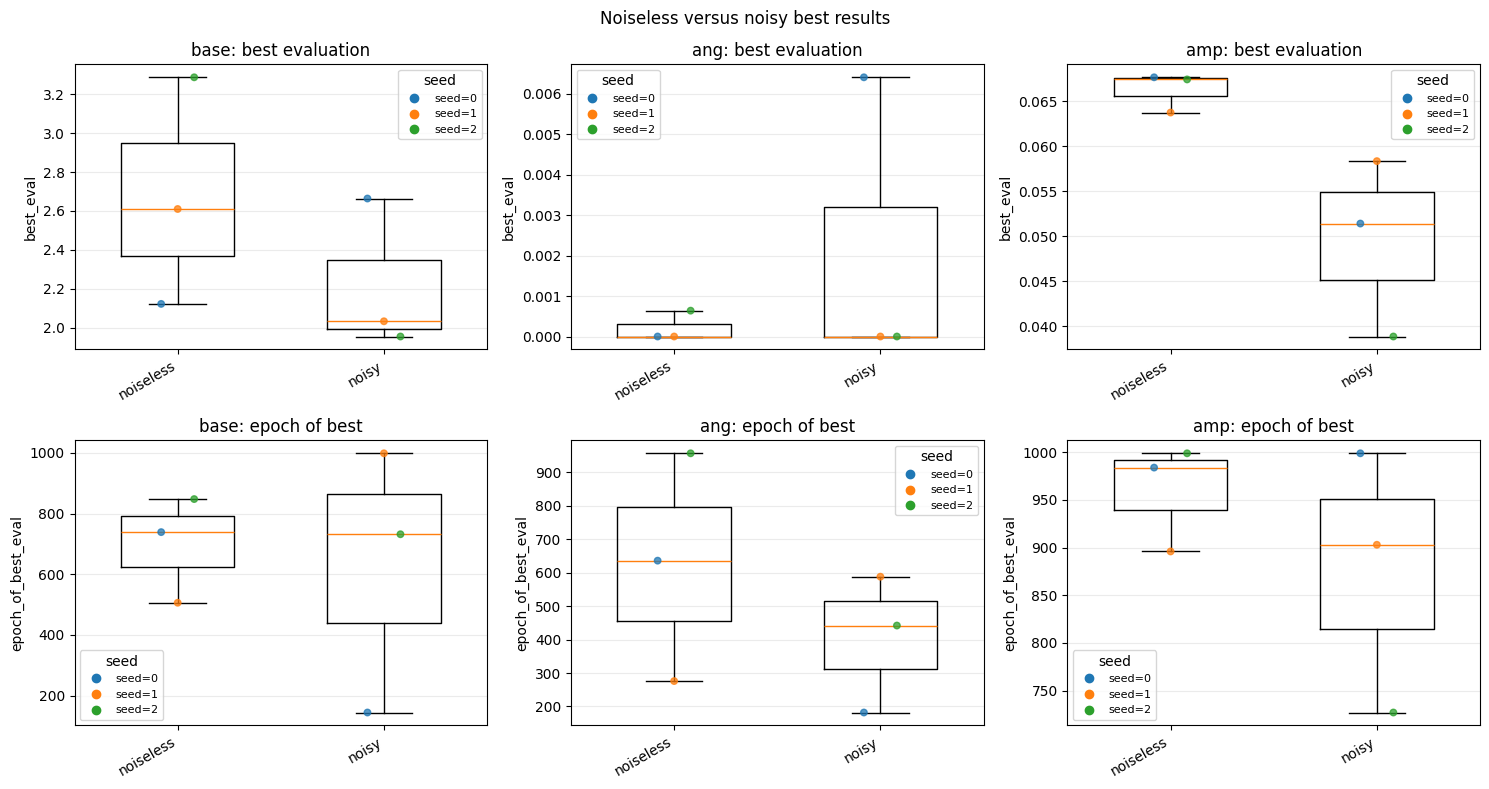

[RunResult(path=PosixPath('/home/benat/Qiskit-IBM/qgan/data/train/amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0'), config={'implementation': {'name': 'qml_torch', 'discriminator_packing': 'separate'}, 'run': {'id': 'amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0', 'label': None, 'data_path': 'qgan/data/train', 'seed': 0, 'device': 'CPU'}, 'experiment': {'implementation': 'amp', 'execution_type': 'noiseless', 'n_qubits': 4, 'gradient_method': 'SPSA'}, 'training': {'max_iterations': 1000, 'gen_iterations': 1, 'disc_iterations': 1, 'init_scale': 0.1, 'learning_rate': 0.005, 'print_every': 10, 'checkpoint_every': 10}, 'dataset': {'id': 'generated_gradients-total_pixels16', 'reset': False, 'type': 'classical', 'source': 'generated_gradients', 'parameters': {'total_pixels': 16}}, 'circuits': {'reset': False, 'generator': 'real_amplitudes', 'discriminator': 'efficient_su2'}, 'backend': {'reset': False, 'save_backend_file': False, 'precision': 0.015625, 'transpilation': {'optimization

In [20]:
report.simulation_execution_best_results(
    simulation_execution_runs,
    presets=PRESET_ORDER,
)

#### 3.2 Noiseless, noisy, and real hardware

The two available real-QPU runs are compared against matching simulator runs truncated to the same observed epoch budget. This is behavioral evidence for those runs, not a replicated estimate of hardware performance.


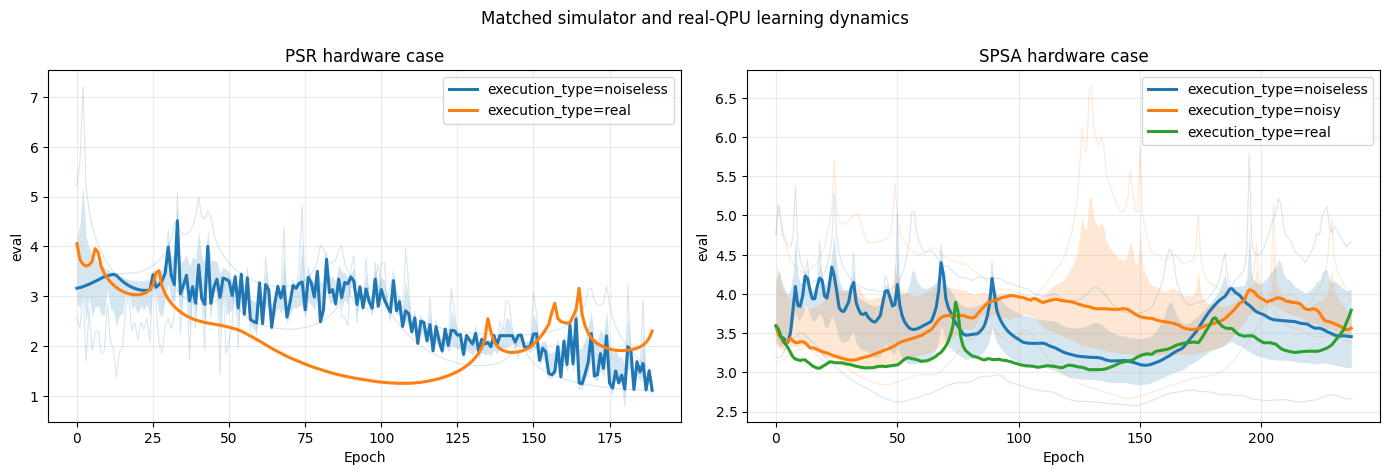

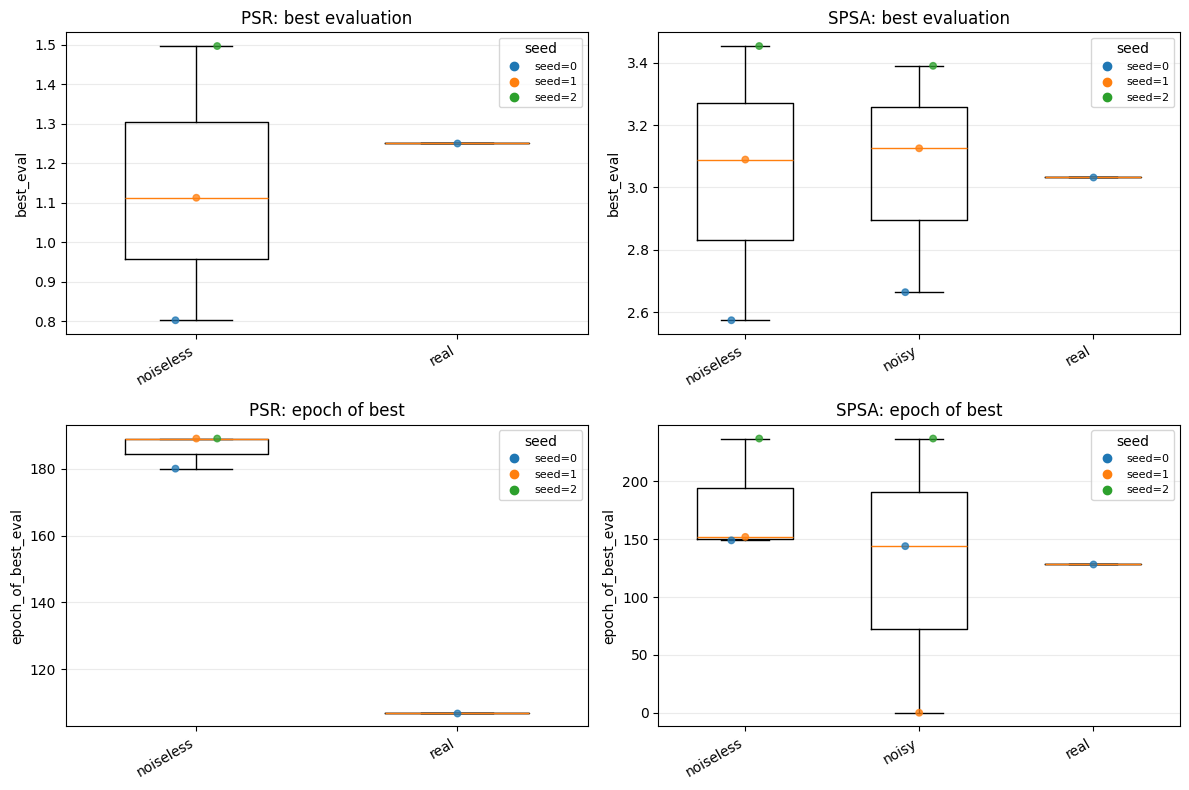

{'run_id': 'base-qml_torch-q4-real-PSR-aerCPU-rand0-seed0', 'gradient_method': 'PSR', 'completed_epochs': 190, 'best_eval': 1.2522631658283698, 'epoch_of_best_eval': 107, 'median_time_per_epoch': 302.93765330314636}
{'run_id': 'base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0', 'gradient_method': 'SPSA', 'completed_epochs': 238, 'best_eval': 3.032940695344694, 'epoch_of_best_eval': 129, 'median_time_per_epoch': 168.67176914215088}


In [21]:
REAL_HARDWARE_FOCUS = {
    "execution_type": "real",
    "implementation": "qml_torch",
    "preset": "base",
    "n_qubits": 4,
    "randomness": 0,
}
hardware_cases = report.real_hardware_comparison(
    filters=REAL_HARDWARE_FOCUS,
    eval_method="kl",
)

### 4. Gradient Method Comparison

SPSA, PSR, and REG are compared with preset, execution type, qubits, randomness, and evaluation metric fixed. Timing is absent here because it is analyzed in Section 1.


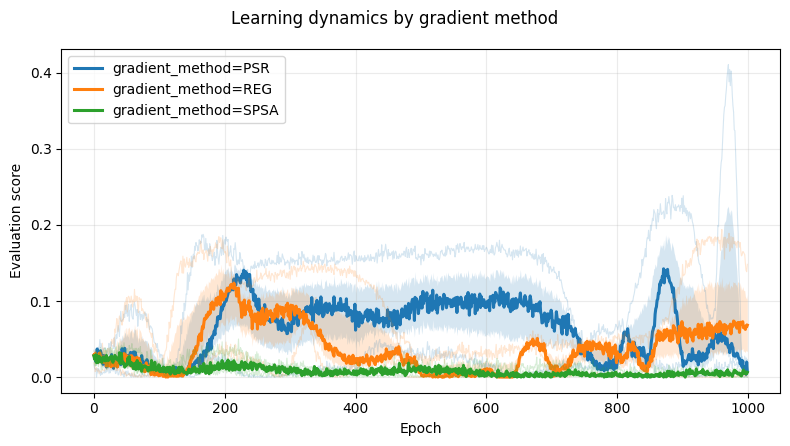

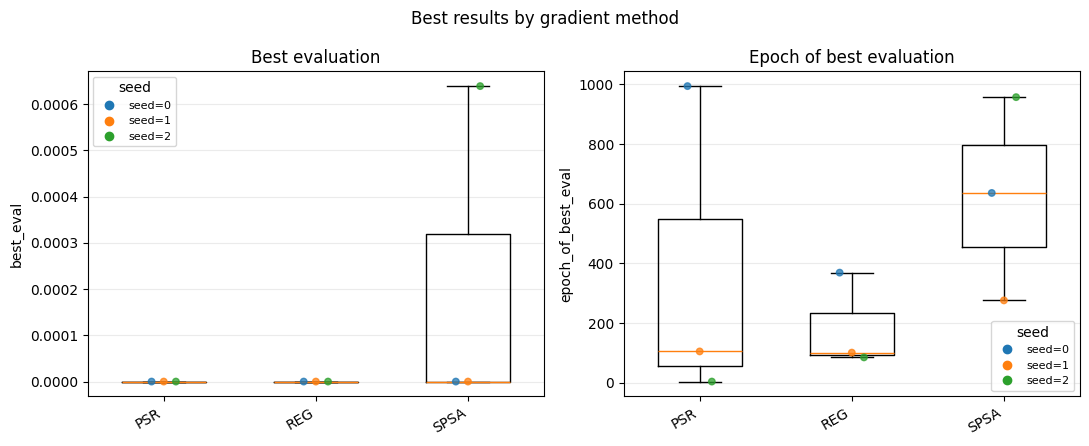

In [22]:
GRADIENT_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "n_qubits": 4,
    "randomness": 0,
    "eval_method": "gradient",
}
gradient_runs = report.gradient_comparison(filters=GRADIENT_FOCUS)

### 5. Randomness Effect

Randomness is first studied as a complete five-level sweep, then with a wider matched `rand0`/`rand1` comparison.


#### 5.1 Complete five-level randomness sweep

The principal analysis requires all five values (`0`, `0.1`, `0.25`, `0.5`, `1`) for seeds 0–2. Evaluation step volatility is the median absolute change between consecutive evaluation scores; larger values indicate a more erratic learning trajectory.


complete five-level × three-seed sweeps: 18
selected sweep: {'preset': 'amp', 'gradient_method': 'PSR', 'n_qubits': 4, 'execution_type': 'noiseless', 'eval_method': 'gradient'}


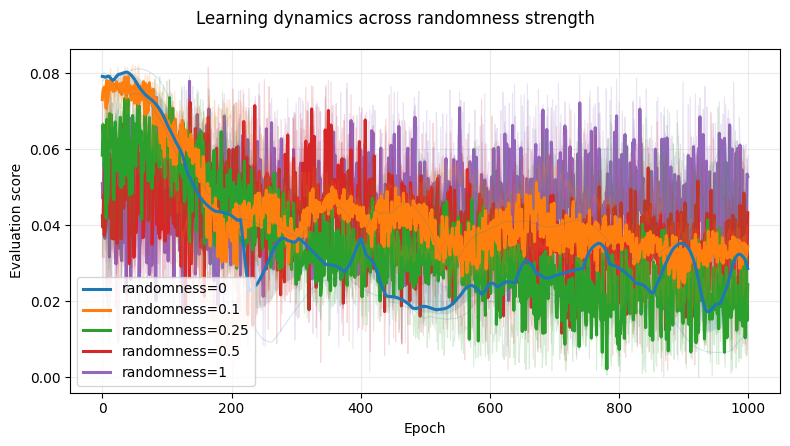

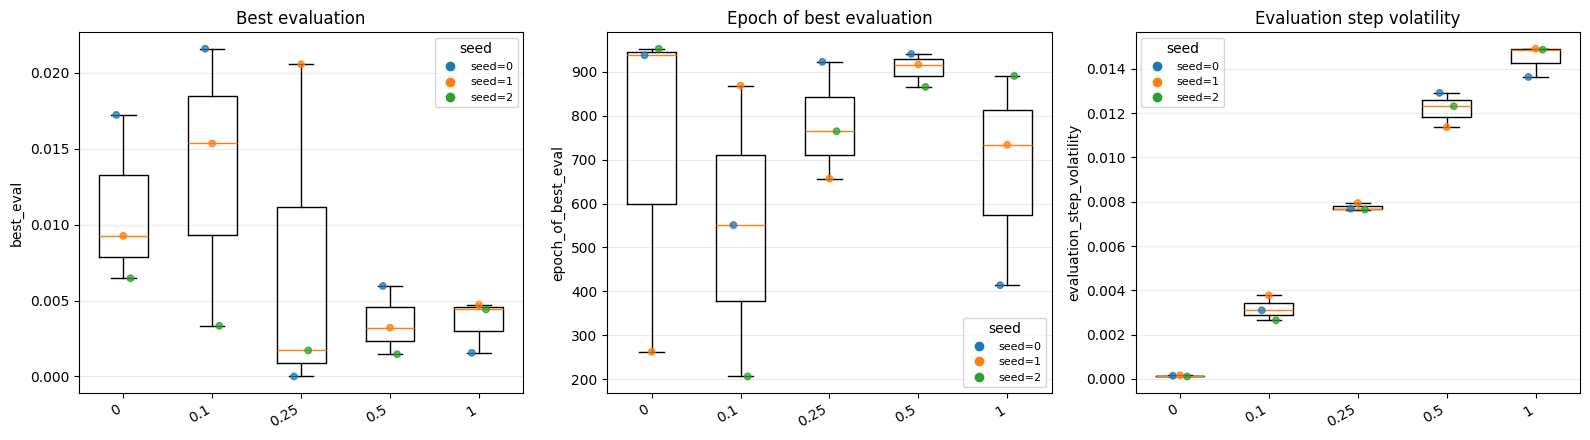

In [23]:
RANDOMNESS_LEVELS = (0, 0.1, 0.25, 0.5, 1)
RANDOMNESS_SEEDS = (0, 1, 2)
RANDOMNESS_SWEEP_INDEX = 0

randomness_main = report.randomness_sweep(
    levels=RANDOMNESS_LEVELS,
    required_seeds=RANDOMNESS_SEEDS,
    sweep_index=RANDOMNESS_SWEEP_INDEX,
)

#### 5.2 Wider paired rand0/rand1 evidence

The wider dataset is reduced to matched `rand0` and `rand1` pairs. Panels show the change in best evaluation, best epoch, and evaluation step volatility. Zero means no effect; positive score or volatility deltas mean worse or bumpier behavior.


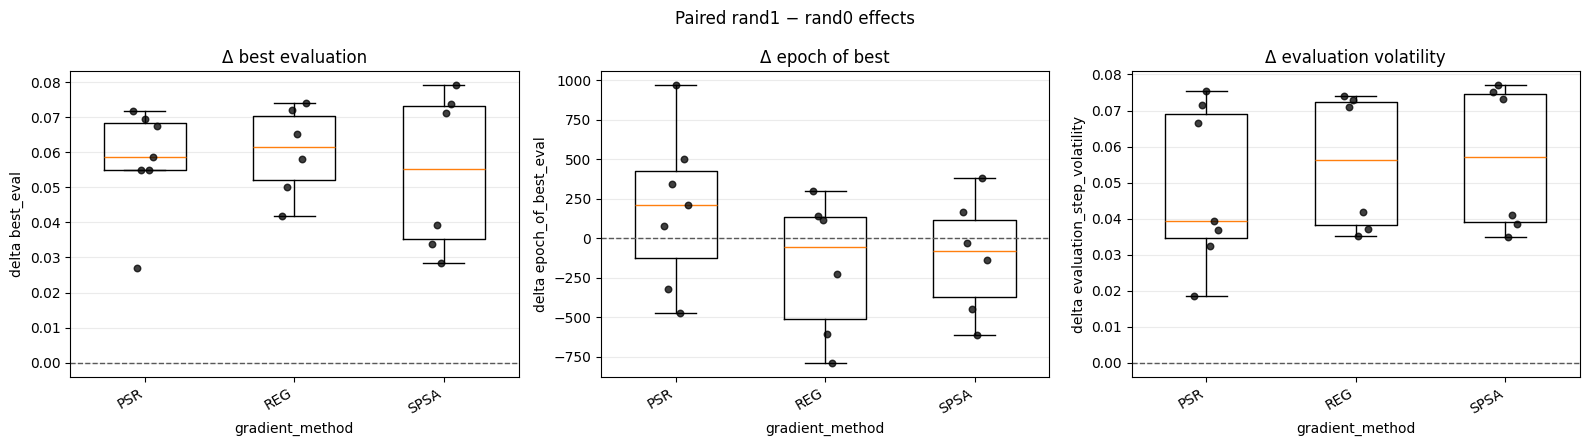

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Δ best evaluation'}, xlabel='gradient_method', ylabel='delta best_eval'>,
        <Axes: title={'center': 'Δ epoch of best'}, xlabel='gradient_method', ylabel='delta epoch_of_best_eval'>,
        <Axes: title={'center': 'Δ evaluation volatility'}, xlabel='gradient_method', ylabel='delta evaluation_step_volatility'>],
       dtype=object))

In [24]:
RANDOMNESS_PAIR_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "eval_method": "gradient",
}
report.randomness_pairs(
    filters=RANDOMNESS_PAIR_FOCUS,
    baseline=0,
    treatment=1,
)

### 6. Scaling Analysis

Scaling is split into preset, execution type, gradient method, and randomness. Each subsection contains representative evaluation dynamics plus best-evaluation and best-epoch scaling across qubit counts. Parameter-count and circuit-width figures are intentionally reserved for the experimental-setup chapter.


#### 6.1 Scaling by preset

Noiseless SPSA and `rand0` are fixed. Each preset is faceted to respect its evaluation metric; qubit count is the compared curve within each facet.


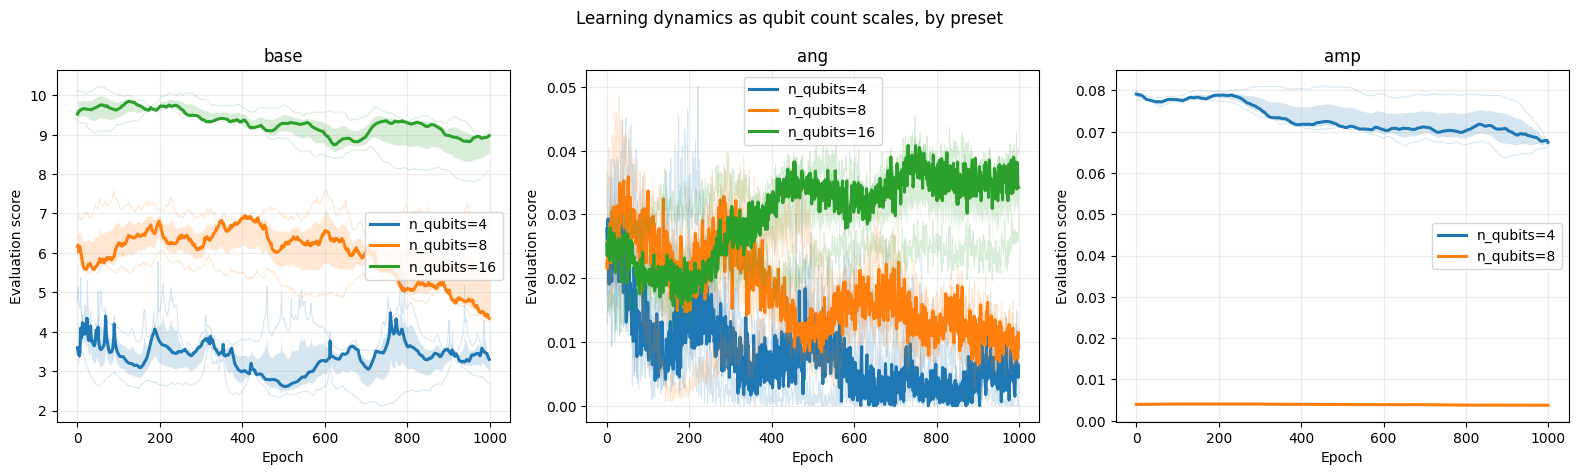

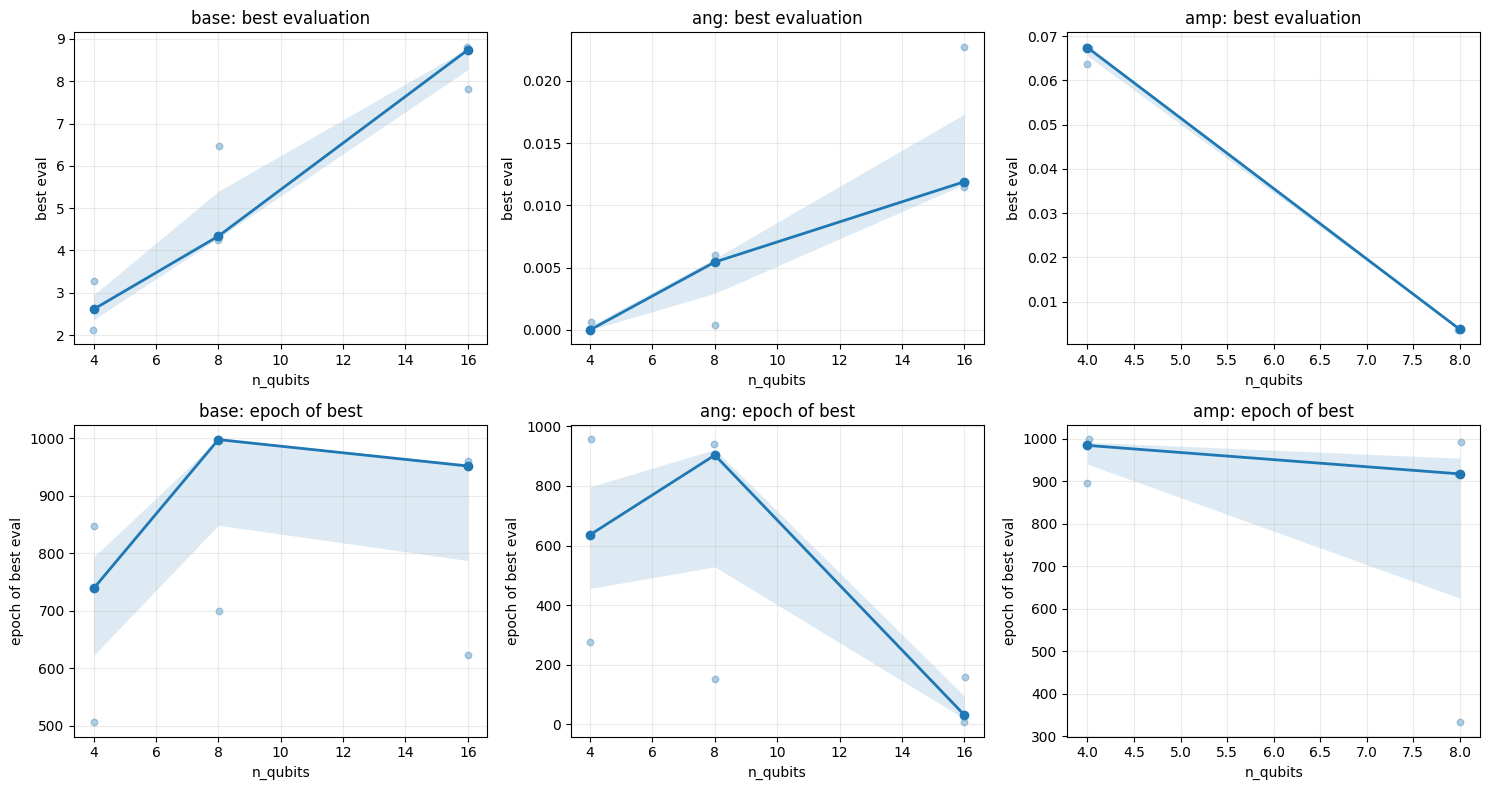

In [25]:
PRESET_SCALING_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "SPSA",
    "randomness": 0,
}
preset_scaling_runs = report.preset_scaling(
    filters=PRESET_SCALING_FOCUS,
    presets=PRESET_ORDER,
    qubits_by_preset={"amp": (4, 8)},
)

#### 6.2 Scaling by execution type

The dynamics are split into noiseless and noisy panels for `ang`, SPSA, and `rand0`. Within each panel, curves compare the available qubit counts. No noisy `q16` result is inferred.


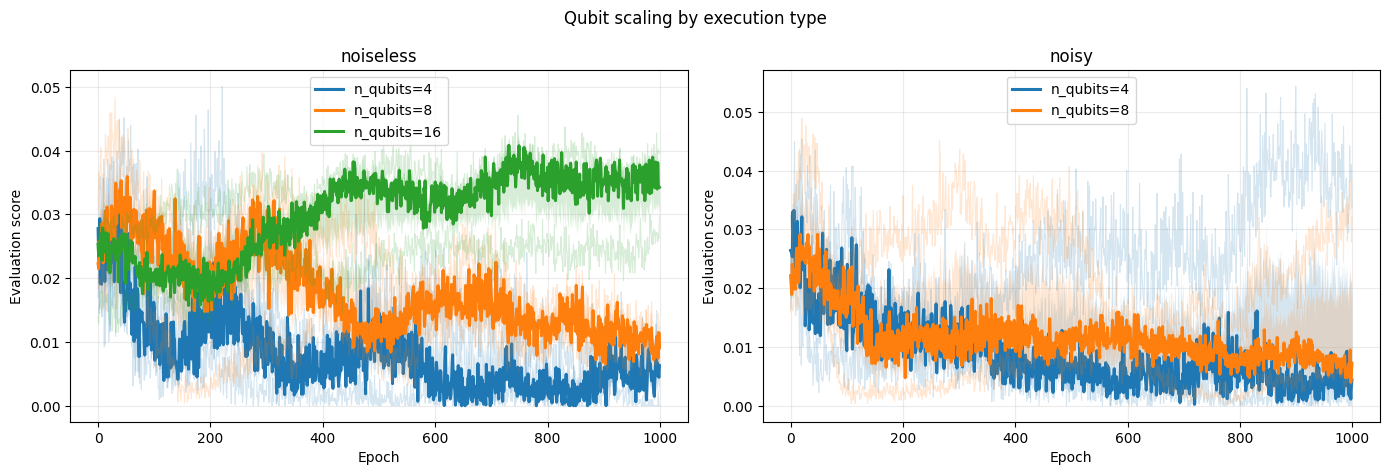

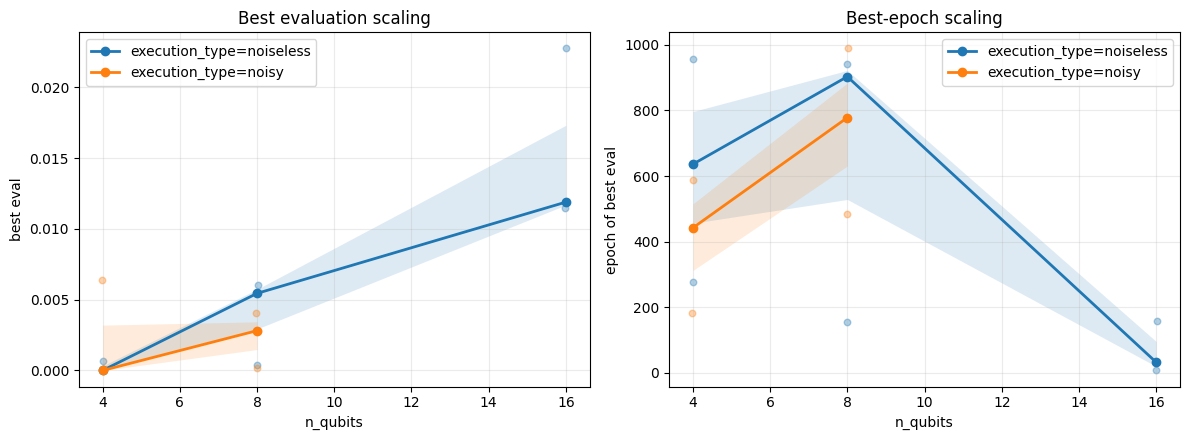

In [26]:
EXECUTION_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "gradient_method": "SPSA",
    "randomness": 0,
}
EXECUTION_TYPES = ("noiseless", "noisy")
execution_scaling_runs = report.execution_scaling(
    filters=EXECUTION_SCALING_FOCUS,
    execution_types=EXECUTION_TYPES,
)

#### 6.3 Scaling by gradient method

The dynamics are split into PSR, REG, and SPSA panels for `ang`, noiseless execution, and `rand0`. Within each panel, curves compare the available qubit counts.


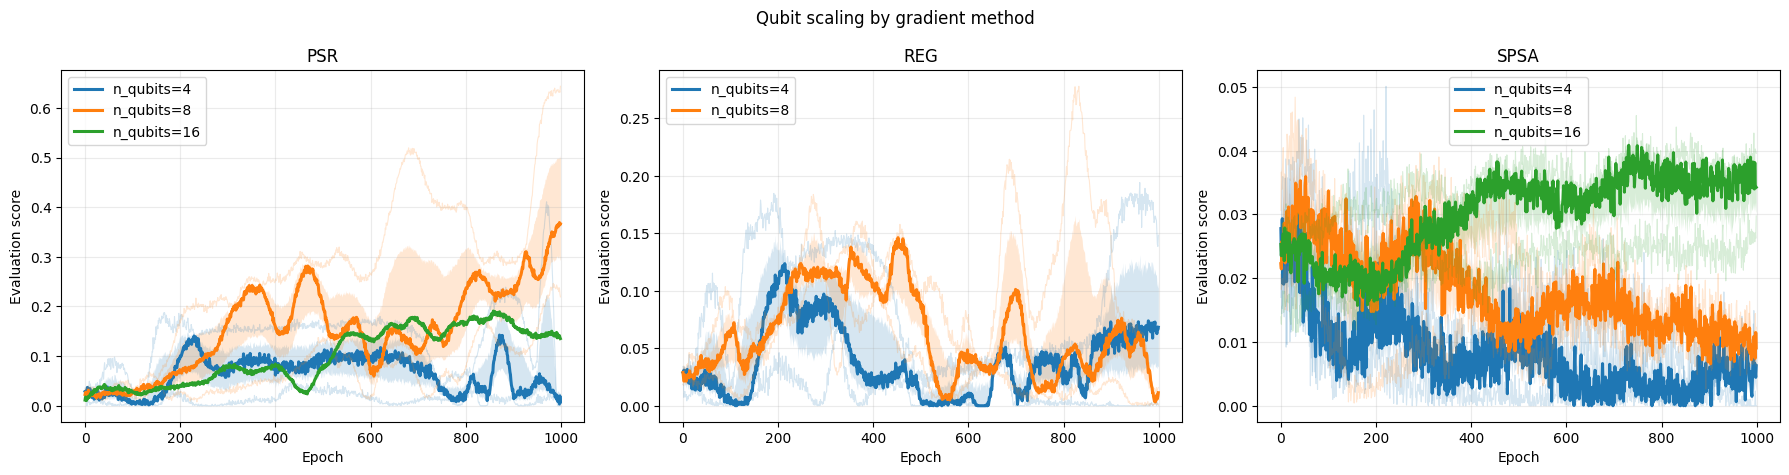

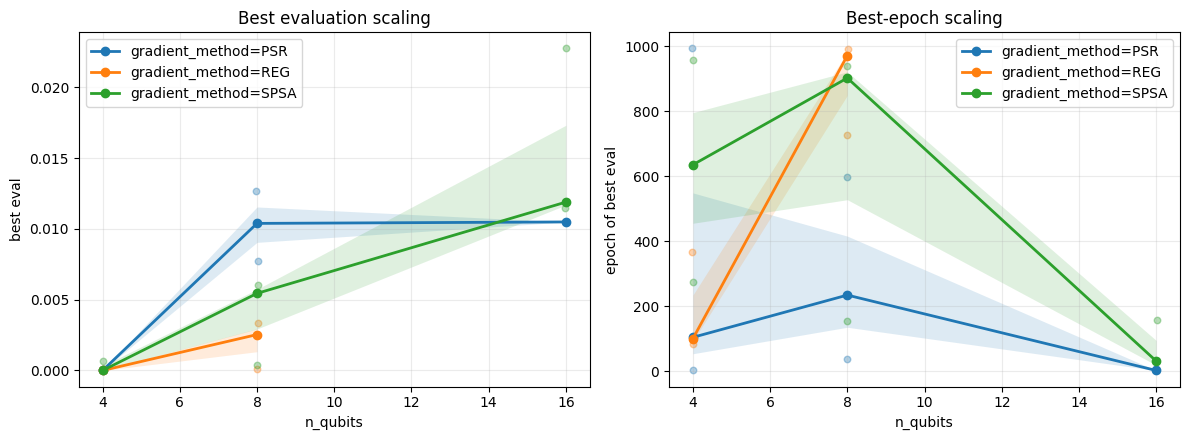

In [27]:
GRADIENT_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "randomness": 0,
}
gradient_scaling_runs = report.gradient_scaling(
    filters=GRADIENT_SCALING_FOCUS,
    gradient_methods=GRADIENT_ORDER,
)

#### 6.4 Scaling by randomness

The dynamics are split into `rand0` and `rand1` panels for `ang`, noiseless SPSA. Within each panel, curves compare the available qubit counts.


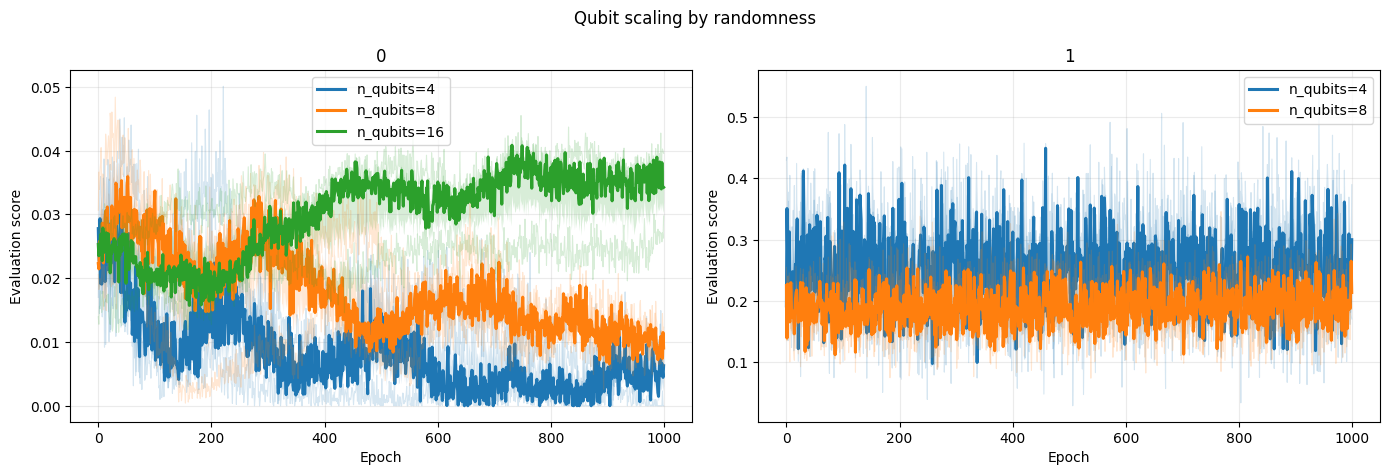

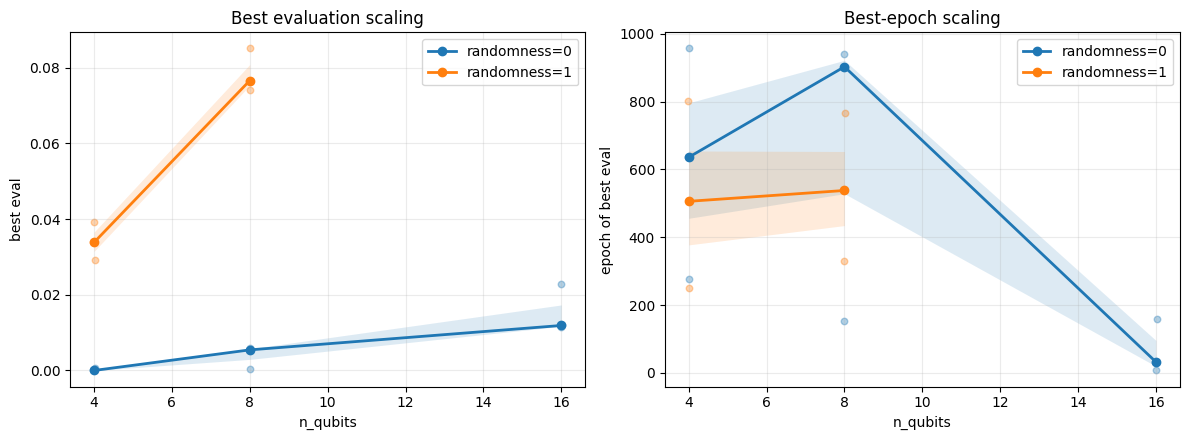

In [28]:
RANDOMNESS_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "SPSA",
}
RANDOMNESS_SCALING_LEVELS = (0, 1)
randomness_scaling_runs = report.randomness_scaling(
    filters=RANDOMNESS_SCALING_FOCUS,
    randomness_levels=RANDOMNESS_SCALING_LEVELS,
)

### 7. Implementation and Packing Validation

This final section only demonstrates that each implementation path trains. Fake-real `q4`, SPSA, `rand0`, seed-0 traces cover `qml_torch`, `runtime_packed/separate`, and valid `runtime_packed/joined` cases. No deep quality, timing, or statistical claim is made from one seed.


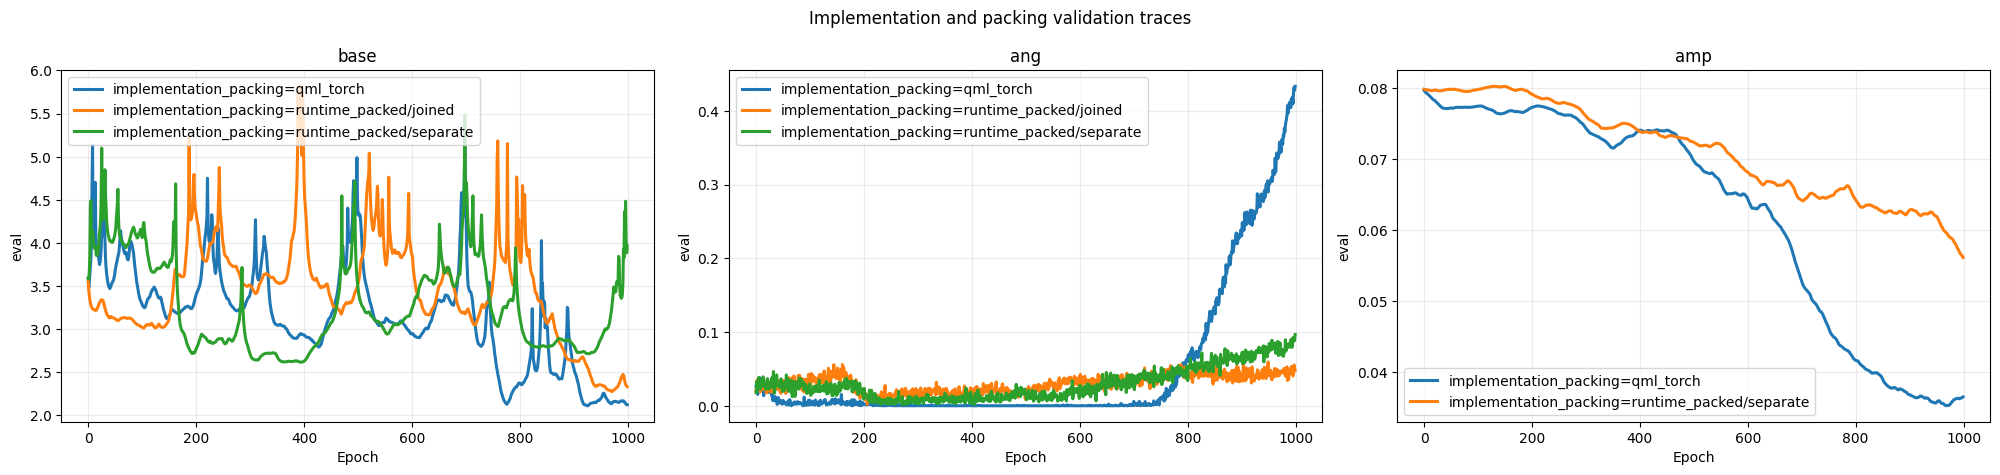

{'run_id': 'amp-qml_torch-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'amp', 'implementation_packing': 'qml_torch', 'completed_epochs': 1000, 'best_eval': 0.03519801034232682, 'epoch_of_best_eval': 969}
{'run_id': 'amp-runtime_packed-separate-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'amp', 'implementation_packing': 'runtime_packed/separate', 'completed_epochs': 1000, 'best_eval': 0.05607925661721558, 'epoch_of_best_eval': 999}
{'run_id': 'ang-qml_torch-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'ang', 'implementation_packing': 'qml_torch', 'completed_epochs': 1000, 'best_eval': -0.0, 'epoch_of_best_eval': 65}
{'run_id': 'ang-runtime_packed-joined-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'ang', 'implementation_packing': 'runtime_packed/joined', 'completed_epochs': 1000, 'best_eval': 0.002163238823413849, 'epoch_of_best_eval': 206}
{'run_id': 'ang-runtime_packed-separate-q4-fake_real-SPSA-aerCPU-rand0-seed0', 'preset': 'ang', 'implementation_packing': 'runtime_

In [29]:
VALIDATION_FOCUS = {
    "execution_type": "fake_real",
    "n_qubits": 4,
    "gradient_method": "SPSA",
    "randomness": 0,
    "seed": 0,
}
fake_validation = report.implementation_validation(
    filters=VALIDATION_FOCUS,
    presets=PRESET_ORDER,
)